In [9]:
import os, sys
from pathlib import Path

In [ ]:
Path(".").resolve()

In [ ]:
img_dir = Path("data/images")
imgs = list(img_dir.rglob("*.jpg")) + list(img_dir.rglob("*.png"))
len(imgs), imgs[:3]

In [ ]:
!pip -q install fiftyone

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

## 1. Анализ производительности, качества и устойчивости в пайплайнах компьютерного зрения

В этом ноутбуке я провожу экспериментальное исследование тестового пайплайна обработки изображений. Цель работы состоит в том, чтобы понять, как параметры обработки влияют на время выполнения, качество результата и устойчивость пайплайна на разных типах входных данных. В ходе исследования я сравниваю несколько наборов изображений, анализирую задержку и разброс измерений, оцениваю качество после изменения размера и рассматриваю поведение пайплайна на искаженных данных

## 2. Состав исследуемых данных

В работе используются три основных среза изображений:
- Набор clean применяется как базовый сценарий для сравнения конфигураций в относительно стабильных условиях
- Набор hard содержит более сложные примеры и используется для оценки поведения пайплайна на трудных случаях
- Набор high_res включает изображения высокого разрешения и позволяет исследовать рост вычислительной нагрузки на более тяжелом входе

Такое разделение помогает сравнивать не только среднее поведение системы, но и ее чувствительность к различным типам данных

In [10]:
from pathlib import Path
from PIL import Image
import shutil

BASE = Path("/content/drive/MyDrive/kursovaya_images")
CLEAN_DIR = BASE / "clean"
HIGH_DIR = BASE / "high-res_large"
HIGH_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for p in list(CLEAN_DIR.glob("*.jpg")) + list(CLEAN_DIR.glob("*.jpeg")) + list(CLEAN_DIR.glob("*.png")):
    try:
        w, h = Image.open(p).size
        rows.append((max(w, h), w*h, p))
    except Exception:
        pass

rows.sort(reverse=True, key=lambda x: (x[0], x[1]))

N = 200
for _, _, p in rows[:N]:
    shutil.copy2(p, HIGH_DIR / p.name)

len(list(HIGH_DIR.glob("*")))

302

В этой ячейке из папки clean выбираются самые крупные изображения по размеру и копируются в отдельную папку high_res_large. Сначала для каждого файла считаются ширина и высота, потом изображения сортируются по размеру и берутся первые 200. В конце выводится количество файлов, которые удалось собрать в новый набор

In [11]:
import os
import shutil
from pathlib import Path
import fiftyone.zoo as foz

CLEAN_DIR.mkdir(parents=True, exist_ok=True)

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=[],
    max_samples=500,
    dataset_name="oi_v7_clean_500",
)

src_dir = Path(dataset.first().filepath).parent

cnt = 0
for p in sorted(src_dir.glob("*")):
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}:
        shutil.copy2(p, CLEAN_DIR / p.name)
        cnt += 1

cnt

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/open-images-v7/validation' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/validation/validation-images-with-rotation.csv' to '/root/fiftyone/open-images-v7/validation/metadata/image_ids.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/validation/metadata/classes.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/bbox_labels_600_hierarchy.json' to '/tmp/tmpqpi899rn/metadata/hierarchy.json'


...

 100% |█████████████████| 500/500 [145.4ms elapsed, 0s remaining, 3.5K samples/s]  


INFO:eta.core.utils: 100% |█████████████████| 500/500 [145.4ms elapsed, 0s remaining, 3.5K samples/s]  


Dataset 'oi_v7_clean_500' created


INFO:fiftyone.zoo.datasets:Dataset 'oi_v7_clean_500' created


500

Здесь загружается часть набора open-images-v7 и из него выбираются изображения из валидационной выборки. Затем все подходящие файлы копируются в папку clean, чтобы создать базовый набор данных для дальнейших экспериментов.


In [12]:
from pathlib import Path

img_dir = Path("data/images/stress")
imgs = list(img_dir.rglob("*.jpg")) + list(img_dir.rglob("*.jpeg")) + list(img_dir.rglob("*.png"))
len(imgs), imgs[:3]

(0, [])

In [13]:
from pathlib import Path

img_dir = Path("data/images")
imgs = (
    list(img_dir.rglob("*.jpg"))
    + list(img_dir.rglob("*.jpeg"))
    + list(img_dir.rglob("*.png"))
)
len(imgs), imgs[:3]

(0, [])

In [14]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


В этих ячейках прроверила, что нет изображений в локальных папках  stress и images

Обе проверки показывают, что файлов там нет

После этого подключилась к Google Drive, чтобы работать уже с данными, сохраненными на диске

In [26]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/kursovaya_images")
CLEAN_DIR = BASE / "clean"
HIGH_DIR = BASE / "high-res_large"
HARD_DIR = BASE / "stress_hard_cases"

for d in [CLEAN_DIR, HIGH_DIR, HARD_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BASE

PosixPath('/content/drive/MyDrive/kursovaya_images')

In [16]:
import shutil
from pathlib import Path
import fiftyone.zoo as foz

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=[],
    max_samples=500,
    dataset_name="oi_v7_clean_500",
)

src_dir = Path(dataset.first().filepath).parent

cnt = 0
for p in sorted(src_dir.glob("*")):
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}:
        shutil.copy2(p, CLEAN_DIR / p.name)
        cnt += 1

cnt

INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/open-images-v7/validation' if necessary


Necessary images already downloaded


INFO:fiftyone.utils.openimages:Necessary images already downloaded


Existing download of split 'validation' is sufficient


INFO:fiftyone.zoo.datasets:Existing download of split 'validation' is sufficient


Loading existing dataset 'oi_v7_clean_500'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


INFO:fiftyone.zoo.datasets:Loading existing dataset 'oi_v7_clean_500'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


500

Задала основные папки проекта на Google Drive и создала отдельные папки для наборов clean, high_res_large и stress_hard_cases

После загрузила часть набора open-images-v7, из него берутся изображения из валидационной выборки и копируются в папку clean, чтобы подготовить базовый набор данных для экспериментов


In [17]:
imgs = list(CLEAN_DIR.rglob("*.jpg")) + list(CLEAN_DIR.rglob("*.jpeg")) + list(CLEAN_DIR.rglob("*.png"))
len(imgs), imgs[:3]

(8000,
 [PosixPath('/content/drive/MyDrive/kursovaya_images/clean/14442c1ee46b9d36.jpg'),
  PosixPath('/content/drive/MyDrive/kursovaya_images/clean/1444b5a29dbbd007.jpg'),
  PosixPath('/content/drive/MyDrive/kursovaya_images/clean/14463f7e6e670c94.jpg')])

In [18]:
from PIL import Image
import shutil

count = 0
for p in list(CLEAN_DIR.glob("*.jpg")) + list(CLEAN_DIR.glob("*.jpeg")) + list(CLEAN_DIR.glob("*.png")):
    try:
        w, h = Image.open(p).size
        if max(w, h) >= 1920:
            shutil.copy2(p, HIGH_DIR / p.name)
            count += 1
    except Exception:
        pass

count

11

In [19]:
from pathlib import Path
from PIL import Image
import shutil

BASE = Path("/content/drive/MyDrive/kursovaya_images")
CLEAN_DIR = BASE / "clean"
HIGH_DIR = BASE / "high-res_large"
HIGH_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for p in list(CLEAN_DIR.glob("*.jpg")) + list(CLEAN_DIR.glob("*.jpeg")) + list(CLEAN_DIR.glob("*.png")):
    try:
        w, h = Image.open(p).size
        rows.append((max(w, h), w*h, p))
    except Exception:
        pass

rows.sort(reverse=True, key=lambda x: (x[0], x[1]))

N = 200
for _, _, p in rows[:N]:
    shutil.copy2(p, HIGH_DIR / p.name)

len(list(HIGH_DIR.glob("*")))

302

In [20]:
!mkdir -p /content/coco
%cd /content/coco
!wget -q http://images.cocodataset.org/zips/val2017.zip
!unzip -q val2017.zip

/content/coco


In [21]:
from pathlib import Path
from PIL import Image

src = Path("/content/coco/val2017")

def count_ge(thresh: int, max_check: int = 2000):
    cnt = 0
    checked = 0
    for p in src.glob("*.jpg"):
        w, h = Image.open(p).size
        if max(w, h) >= thresh:
            cnt += 1
        checked += 1
        if checked >= max_check:
            break
    return cnt, checked

count_ge(1600), count_ge(1280), count_ge(1024)

((0, 2000), (0, 2000), (0, 2000))

Поэтапно проверила:
- Собран базовый набор в clean
- Из этого набора отдельно выделила изображения большого размера, скопировала в папку high_res_large
- Попробовала использовать набор COCO, чтобы найти там подходящие большие изображения, но не нашла ничего подходящего

In [22]:
!ls -la /content/coco
!ls -la /content/coco/val2017 | head
!find /content/coco -maxdepth 2 -type f -name "*.jpg" | head

total 796648
drwxr-xr-x 3 root root      4096 Apr 18 12:10 .
drwxr-xr-x 1 root root      4096 Apr 18 12:09 ..
drwxrwxr-x 2 root root    163840 Aug 31  2017 val2017
-rw-r--r-- 1 root root 815585330 Jul 11  2018 val2017.zip
total 805916
drwxrwxr-x 2 root root 163840 Aug 31  2017 .
drwxr-xr-x 3 root root   4096 Apr 18 12:10 ..
-rw-rw-r-- 1 root root 161811 Aug 16  2014 000000000139.jpg
-rw-rw-r-- 1 root root 335861 Aug 16  2014 000000000285.jpg
-rw-rw-r-- 1 root root 155667 Aug 16  2014 000000000632.jpg
-rw-rw-r-- 1 root root 130107 Aug 16  2014 000000000724.jpg
-rw-rw-r-- 1 root root 176410 Aug 16  2014 000000000776.jpg
-rw-rw-r-- 1 root root 133674 Aug 16  2014 000000000785.jpg
-rw-rw-r-- 1 root root  62406 Aug 16  2014 000000000802.jpg
/content/coco/val2017/000000139099.jpg
/content/coco/val2017/000000500257.jpg
/content/coco/val2017/000000196185.jpg
/content/coco/val2017/000000036660.jpg
/content/coco/val2017/000000043581.jpg
/content/coco/val2017/000000359219.jpg
/content/coco/val201

In [23]:
from pathlib import Path
from PIL import Image
import shutil

src = Path("/content/coco/val2017")
BASE = Path("/content/drive/MyDrive/kursovaya_images")
HIGH_DIR = BASE / "high-res_large"
HIGH_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for p in src.glob("*.jpg"):
    w, h = Image.open(p).size
    rows.append((max(w, h), w*h, p))

rows.sort(reverse=True, key=lambda x: (x[0], x[1]))

N = 200

for f in HIGH_DIR.glob("*"):
    if f.is_file():
        f.unlink()

for _, _, p in rows[:N]:
    shutil.copy2(p, HIGH_DIR / p.name)

len(list(HIGH_DIR.glob("*.jpg")))

200

Проверила, что папка COCO действительно скачана и в ней есть изображения
После этого все файлы из val2017 отсортировала по размеру, старое содержимое папки high_res_large очистила, и в нее скопировала 200 самых крупных изображений для отдельного набора данных

In [24]:
import fiftyone.zoo as foz
from pathlib import Path

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=[],
    max_samples=8000,
    dataset_name="oi_v7_big_pool",
)
src_dir = Path(dataset.first().filepath).parent
src_dir

INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/open-images-v7/validation' if necessary


Found 500 images, downloading the remaining 7500


INFO:fiftyone.utils.openimages:Found 500 images, downloading the remaining 7500


 100% |█████████████████| 7500/7500 [15.9m elapsed, 0s remaining, 7.5 files/s]      


INFO:eta.core.utils: 100% |█████████████████| 7500/7500 [15.9m elapsed, 0s remaining, 7.5 files/s]      


...

 100% |███████████████| 8000/8000 [2.3s elapsed, 0s remaining, 4.0K samples/s]      


INFO:eta.core.utils: 100% |███████████████| 8000/8000 [2.3s elapsed, 0s remaining, 4.0K samples/s]      


Dataset 'oi_v7_big_pool' created


INFO:fiftyone.zoo.datasets:Dataset 'oi_v7_big_pool' created


PosixPath('/root/fiftyone/open-images-v7/validation/data')

In [25]:
from PIL import Image
import shutil
from pathlib import Path

BASE = Path("/content/drive/MyDrive/kursovaya_images")
HIGH_DIR = BASE / "high-res_large"
HIGH_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for p in src_dir.glob("*"):
    if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        continue
    try:
        w, h = Image.open(p).size
        rows.append((max(w, h), w*h, p))
    except Exception:
        pass

rows.sort(reverse=True, key=lambda x: (x[0], x[1]))

N = 200

for f in HIGH_DIR.glob("*"):
    if f.is_file():
        f.unlink()

for _, _, p in rows[:N]:
    shutil.copy2(p, HIGH_DIR / p.name)

len(list(HIGH_DIR.glob("*")))

200

In [27]:
import numpy as np
from PIL import Image
from pathlib import Path

HIGH_DIR = Path("/content/drive/MyDrive/kursovaya_images/high-res_large")
sizes = []
for p in HIGH_DIR.glob("*"):
    try:
        w, h = Image.open(p).size
        sizes.append(max(w, h))
    except Exception:
        pass

arr = np.array(sizes)
arr.min(), int(np.median(arr)), arr.max(), len(arr)

(np.int64(1024), 1024, np.int64(5520), 200)

In [28]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/kursovaya_images")
DATASETS = {
    "clean": BASE / "clean",
    "hard": BASE / "stress_hard_cases",
    "high_res": BASE / "high-res_large",
}

OUT = Path("/content/drive/MyDrive/kursovaya_results")
OUT.mkdir(parents=True, exist_ok=True)

{k: (v.exists(), v) for k, v in DATASETS.items()}, OUT

({'clean': (True, PosixPath('/content/drive/MyDrive/kursovaya_images/clean')),
  'hard': (True,
   PosixPath('/content/drive/MyDrive/kursovaya_images/stress_hard_cases')),
  'high_res': (True,
   PosixPath('/content/drive/MyDrive/kursovaya_images/high-res_large'))},
 PosixPath('/content/drive/MyDrive/kursovaya_results'))

Сначала загрузила большой набор изображений open-images-v7, из которого взяла 8000 файлов, чтобы сформировать более широкий пул данных

Затем из этого пула выбрала 200 самых крупных изображений и сохранила в папку high_res_large, после чего проверила размеры полученного набора и зафиксировала пути ко всем основным датасетам и папке с результатами


In [29]:
from pathlib import Path

def list_images(folder: Path, limit: int = 300):
    imgs = list(folder.rglob("*.jpg")) + list(folder.rglob("*.jpeg")) + list(folder.rglob("*.png"))
    imgs = sorted(imgs)
    return imgs[:limit]

for name, folder in DATASETS.items():
    print(name, len(list_images(folder, limit=1000)))

clean 1000
hard 900
high_res 200


Я задаю функцию, которая собирает изображения из выбранной папки и ограничивает их количество, чтобы дальше работать с единым числом файлов для каждого набора данных.

Затем я прохожусь по всем подготовленным датасетам и вывожу, сколько изображений удалось найти в каждом из них


## 3. Реализация тестового пайплайна

В этой ячейке я задаю тестовый пайплайн обработки одного изображения. Изображение загружается, приводится к нужному размеру, подготавливается для дальнейшей обработки, после чего выполняется основное вычисление и формируется итоговый результат. Для каждого запуска я отдельно измеряю время по этапам, чтобы понять, какие части пайплайна сильнее всего влияют на общую задержку

In [30]:
import time
import numpy as np
from PIL import Image

def run_pipeline(image_path: str, input_size: int = 640):
    t0 = time.perf_counter()
    img = Image.open(image_path).convert("RGB")
    t1 = time.perf_counter()

    t2 = time.perf_counter()
    img = img.resize((input_size, input_size))
    arr = np.asarray(img, dtype=np.uint8)
    t3 = time.perf_counter()

    t4 = time.perf_counter()
    score = float(arr.mean())
    t5 = time.perf_counter()

    t6 = time.perf_counter()
    _ = {"result": score}
    t7 = time.perf_counter()

    return {
        "load_ms": (t1 - t0) * 1000.0,
        "preprocess_ms": (t3 - t2) * 1000.0,
        "inference_ms": (t5 - t4) * 1000.0,
        "postprocess_ms": (t7 - t6) * 1000.0,
        "total_ms": (t7 - t0) * 1000.0,
    }

In [32]:
import pandas as pd
import uuid
from datetime import datetime

def benchmark_dataset(name: str, folder: Path, input_size: int = 640, limit: int = 300, warmup: int = 2, repeats: int = 5):
    imgs = list_images(folder, limit=limit)
    run_id = uuid.uuid4().hex[:10]
    ts = datetime.now().isoformat(timespec="seconds")

    rows = []
    for img_path in imgs:
        for r in range(warmup + repeats):
            m = run_pipeline(str(img_path), input_size=input_size)
            rows.append({
                "run_id": run_id,
                "timestamp": ts,
                "dataset": name,
                "image_path": str(img_path),
                "input_size": input_size,
                "repeat_idx": r,
                "warmup": int(r < warmup),
                **m,
            })

    df = pd.DataFrame(rows)
    out_path = OUT / f"bench_{name}_s{input_size}_{run_id}.csv"
    df.to_csv(out_path, index=False)
    return out_path, df

paths = []
for name, folder in DATASETS.items():
    p, _ = benchmark_dataset(name, folder, input_size=640, limit=200, warmup=2, repeats=5)
    print("saved:", p)
    paths.append(p)

paths

saved: /content/drive/MyDrive/kursovaya_results/bench_clean_s640_7cdfaec624.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_hard_s640_e38a9301b9.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_high_res_s640_9461616b9c.csv


[PosixPath('/content/drive/MyDrive/kursovaya_results/bench_clean_s640_7cdfaec624.csv'),
 PosixPath('/content/drive/MyDrive/kursovaya_results/bench_hard_s640_e38a9301b9.csv'),
 PosixPath('/content/drive/MyDrive/kursovaya_results/bench_high_res_s640_9461616b9c.csv')]

In [33]:
import pandas as pd

dfs = []
for p in paths:
    df = pd.read_csv(p)
    df = df[df["warmup"] == 0].copy()
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

agg = all_df.groupby(["dataset", "input_size"]).agg(
    latency_p50=("total_ms", lambda s: s.quantile(0.5)),
    latency_p95=("total_ms", lambda s: s.quantile(0.95)),
    load_ms=("load_ms", "mean"),
    pre_ms=("preprocess_ms", "mean"),
    inf_ms=("inference_ms", "mean"),
    post_ms=("postprocess_ms", "mean"),
).reset_index()

agg

,dataset,input_size,latency_p50,latency_p95,load_ms,pre_ms,inf_ms,post_ms
0,clean,640,34.890339,83.078790,127.517927,21.865563,1.374487,0.001289
1,hard,640,29.342157,47.484964,81.771060,20.276483,1.217545,0.001340
2,high_res,640,35.622725,158.494699,25.906839,30.801429,1.210663,0.001570


В этой части я запускаю серию измерений для каждого подготовленного набора данных и сохраняю результаты прогонов в отдельные csv файлы. После этого я объединяю полученные таблицы, исключаю прогревочные запуски и рассчитываю основные агрегированные метрики, чтобы сравнить наборы данных по задержке обработки и по вкладу отдельных этапов пайплайна

## 4. Оценка разброса измерений

Помимо медианы и верхнего квантиля полезно отдельно посмотреть на разброс измерений. Это помогает понять, насколько стабильны результаты внутри каждой конфигурации и насколько велико отклонение отдельных прогонов от типичного значения

In [41]:
var_agg = all_df.groupby(["dataset", "input_size"]).agg(
    latency_mean=("total_ms", "mean"),
    latency_std=("total_ms", "std"),
    latency_q25=("total_ms", lambda s: s.quantile(0.25)),
    latency_q75=("total_ms", lambda s: s.quantile(0.75)),
).reset_index()

var_agg["latency_iqr"] = var_agg["latency_q75"] - var_agg["latency_q25"]
var_agg.sort_values(["dataset", "input_size"])

,dataset,input_size,latency_mean,latency_std,latency_q25,latency_q75,latency_iqr
0,clean,640,150.761835,2405.376672,28.081189,43.219298,15.138109
1,hard,640,103.269136,2156.012989,24.528718,38.182936,13.654219
2,high_res,640,57.923157,85.569608,32.604062,49.135721,16.531659


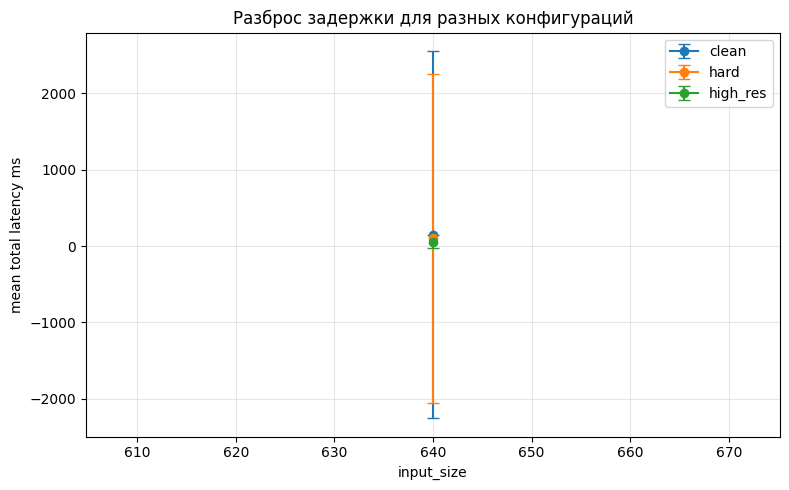

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for ds in sorted(var_agg["dataset"].unique()):
    sub = var_agg[var_agg["dataset"] == ds].sort_values("input_size")
    plt.errorbar(
        sub["input_size"],
        sub["latency_mean"],
        yerr=sub["latency_std"],
        marker="o",
        capsize=4,
        label=ds,
    )

plt.xlabel("input_size")
plt.ylabel("mean total latency ms")
plt.title("Разброс задержки для разных конфигураций")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Этот график показывает, насколько стабильны измерения внутри каждой конфигурации. Чем больше разброс, тем менее предсказуемо поведение пайплайна даже при одинаковых настройках

В этой части я дополнительно оцениваю, насколько стабильны результаты внутри каждой конфигурации

Для этого я считаю среднее значение задержки, стандартное отклонение и межквартильный размах, а затем строю график, который показывает, насколько сильно отдельные прогоны отклоняются от типичного уровня

По этим результатам я могу судить не только о средней скорости работы пайплайна, но и о предсказуемости его поведения на разных наборах данных


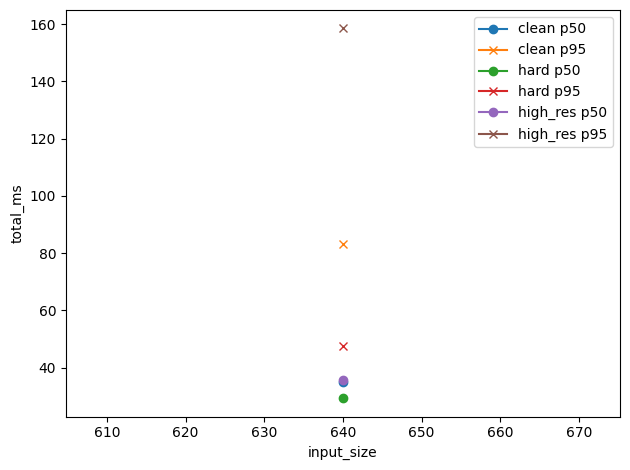

In [36]:
import matplotlib.pyplot as plt

plt.figure()
for ds in sorted(agg["dataset"].unique()):
    sub = agg[agg["dataset"] == ds].sort_values("input_size")
    plt.plot(sub["input_size"], sub["latency_p50"], marker="o", label=f"{ds} p50")
    plt.plot(sub["input_size"], sub["latency_p95"], marker="x", label=f"{ds} p95")

plt.xlabel("input_size")
plt.ylabel("total_ms")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
def fmt(ms):
    return f"{ms:.1f} ms"

for ds in sorted(agg["dataset"].unique()):
    sub = agg[(agg["dataset"] == ds) & (agg["input_size"] == 640)].iloc[0]
    print(ds, "p50:", fmt(sub["latency_p50"]), "p95:", fmt(sub["latency_p95"]),
          "| pre:", fmt(sub["pre_ms"]), "inf:", fmt(sub["inf_ms"]))

clean p50: 34.9 ms p95: 83.1 ms | pre: 21.9 ms inf: 1.4 ms
hard p50: 29.3 ms p95: 47.5 ms | pre: 20.3 ms inf: 1.2 ms
high_res p50: 35.6 ms p95: 158.5 ms | pre: 30.8 ms inf: 1.2 ms


In [38]:
from pathlib import Path

OUT = Path("/content/drive/MyDrive/kursovaya_results")
OUT.mkdir(parents=True, exist_ok=True)

agg_path = OUT / "agg_summary.csv"
agg.to_csv(agg_path, index=False)
agg_path

PosixPath('/content/drive/MyDrive/kursovaya_results/agg_summary.csv')

Здесь я сравниваю наборы данных по медианной задержке и верхнему квантилю, чтобы увидеть не только типичное время обработки, но и более тяжелые случаи

Отдельно вывожу ключевые метрики в компактном виде и сохраняю агрегированную таблицу с результатами для дальнейшего анализа и использования в итоговых материалах

## 5. Воспроизводимость измерений

Для повышения воспроизводимости в работе фиксируются структура наборов данных, параметры прогонов и сохраняются агрегированные таблицы результатов и визуализации. Использование единого протокола измерений и одинаковых конфигураций для разных срезов данных позволяет получать сопоставимые результаты и повторно анализировать поведение пайплайна без изменения логики эксперимента.

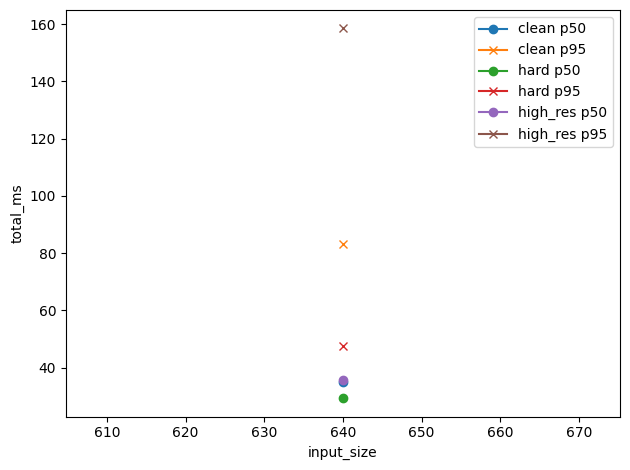

In [42]:
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("/content/drive/MyDrive/kursovaya_results/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure()
for ds in sorted(agg["dataset"].unique()):
    sub = agg[agg["dataset"] == ds].sort_values("input_size")
    plt.plot(sub["input_size"], sub["latency_p50"], marker="o", label=f"{ds} p50")
    plt.plot(sub["input_size"], sub["latency_p95"], marker="x", label=f"{ds} p95")
plt.xlabel("input_size")
plt.ylabel("total_ms")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "latency_p50_p95_vs_input_size.png", dpi=200)
plt.show()

Здесь я фиксирую результаты измерений и сохраняю построенный график в отдельную папку, чтобы потом использовать его в анализе, отчете и презентации. Это нужно для того, чтобы все ключевые выводы по производительности можно было воспроизвести и повторно проверить без повторного запуска всей серии экспериментов

In [48]:
import numpy as np
from PIL import Image
import math

def psnr(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return float("inf")
    return 20.0 * math.log10(255.0) - 10.0 * math.log10(mse)

def resize_roundtrip_psnr(image_path: str, input_size: int) -> float:
    img = Image.open(image_path).convert("RGB")
    w0, h0 = img.size
    small = img.resize((input_size, input_size))
    back = small.resize((w0, h0))
    return psnr(np.asarray(img), np.asarray(back))

Я задаю функцию для расчета PSNR и использую ее, чтобы оценивать, насколько сильно изменяется изображение после уменьшения и обратного восстановления размера. Эта метрика помогает мне сравнивать конфигурации не только по скорости работы, но и по сохранению качества изображения

## 6. Дополнительная метрика качества

Для более полного анализа качества изображения после изменения размера далее используется не только PSNR, но и SSIM. Метрика PSNR отражает среднее пиксельное отличие, а SSIM лучше показывает сохранение структуры изображения. Совместное использование этих двух метрик делает сравнение конфигураций более надежным

In [50]:
from skimage.metrics import structural_similarity as ssim

def resize_roundtrip_ssim(image_path: str, input_size: int) -> float:
    img = Image.open(image_path).convert("RGB")
    w0, h0 = img.size
    small = img.resize((input_size, input_size))
    back = small.resize((w0, h0))
    return float(
        ssim(
            np.asarray(img),
            np.asarray(back),
            channel_axis=2,
            data_range=255,
        )
    )

## 7. Расширенная таблица качества

Ниже формируется расширенная таблица метрик качества. Для каждого набора данных и каждого размера входа считаются усредненные показатели PSNR и SSIM, а также нижние квантили, которые помогают увидеть более слабые случаи

In [52]:
imgs = list_images(folder, limit=120)

In [55]:
from pathlib import Path

def list_images(folder: Path, limit: int = 300):
    imgs = list(folder.rglob("*.jpg")) + list(folder.rglob("*.jpeg")) + list(folder.rglob("*.png"))
    imgs = sorted(imgs)
    return imgs[:limit]

## 8. Протокол эксперимента

В этой части я задаю единый протокол измерений для всех экспериментов. Для каждого набора данных я выполняю прогоны при нескольких значениях размера входного изображения, отдельно выделяю прогревочные запуски и собираю повторные измерения для расчета агрегированных метрик. В дальнейшем я использую медиану, верхний квантиль, среднее значение и показатели разброса, чтобы сравнивать конфигурации в одинаковых и воспроизводимых условиях

In [57]:
import pandas as pd
import numpy as np

rows = []
for ds_name, folder in DATASETS.items():
    imgs = list_images(folder, limit=30)
    for size in [320, 640, 960]:
        psnr_vals = [resize_roundtrip_psnr(str(p), size) for p in imgs]
        ssim_vals = [resize_roundtrip_ssim(str(p), size) for p in imgs]
        rows.append({
            "dataset": ds_name,
            "input_size": size,
            "psnr_mean": float(np.mean(psnr_vals)),
            "psnr_p10": float(np.quantile(psnr_vals, 0.10)),
            "ssim_mean": float(np.mean(ssim_vals)),
            "ssim_p10": float(np.quantile(ssim_vals, 0.10)),
        })

q_agg = pd.DataFrame(rows)
q_agg

,dataset,input_size,psnr_mean,psnr_p10,ssim_mean,ssim_p10
0,clean,320,33.564961,25.161369,0.911134,0.788029
1,clean,640,40.541176,31.854077,0.975838,0.959058
2,clean,960,45.558079,34.905129,0.990683,0.987276
3,hard,320,35.496676,25.405067,0.811609,0.485112
4,hard,640,40.899767,27.513824,0.909145,0.736939
5,hard,960,44.715866,31.944413,0.964366,0.893627
6,high_res,320,32.934082,27.531924,0.903712,0.811168
7,high_res,640,41.134474,33.733083,0.975924,0.956355
8,high_res,960,46.730213,39.640500,0.990521,0.990074


По полученным результатам видно, что с увеличением размера входного изображения значения PSNR и SSIM растут для всех наборов данных. Это означает, что при более крупном размере входа изображение после преобразования сохраняет больше визуальной информации и лучше сохраняет свою структуру

Наиболее заметно различие проявляется на размере 320, где качество ниже у всех наборов данных, особенно по SSIM. Набор hard оказывается самым чувствительным к уменьшению размера, так как именно для него наблюдаются самые низкие значения SSIM и нижнего квантиля. При размере 960 показатели качества становятся наиболее высокими для всех наборов, что подтверждает ожидаемый компромисс между скоростью обработки и сохранением качества изображения

## 9. Анализ структурного качества изображения

Помимо PSNR, в работе используется метрика SSIM, которая позволяет оценить, насколько хорошо после изменения размера сохраняется структура изображения. Это делает сравнение конфигураций более содержательным, так как качество оценивается не только по среднему пиксельному отличию, но и по степени структурного сходства

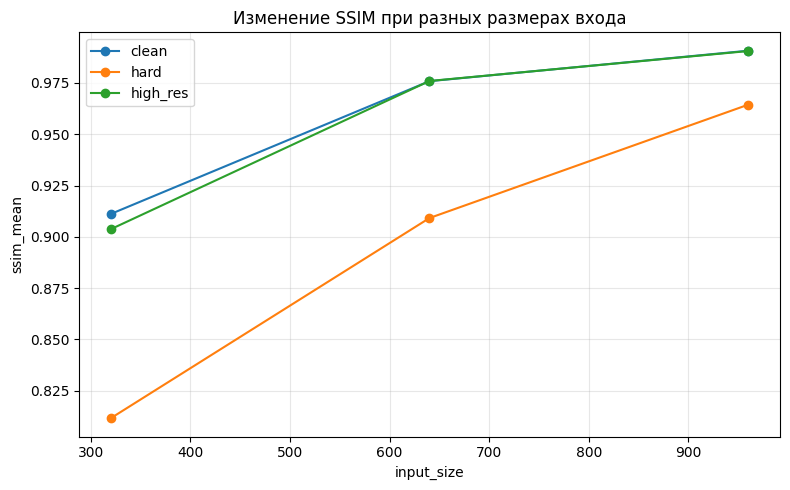

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for ds in sorted(q_agg["dataset"].unique()):
    sub = q_agg[q_agg["dataset"] == ds].sort_values("input_size")
    plt.plot(sub["input_size"], sub["ssim_mean"], marker="o", label=ds)

plt.xlabel("input_size")
plt.ylabel("ssim_mean")
plt.title("Изменение SSIM при разных размерах входа")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

По графику видно, что с увеличением размера входа значение SSIM растет для всех наборов данных, то есть структура изображения после преобразования сохраняется лучше. Наиболее чувствительным к уменьшению размера оказывается набор hard, так как при input size 320 у него наблюдается самое низкое значение SSIM. Для clean и high_res качество остается более стабильным, а при размере 960 все наборы показывают наиболее высокие значения

Результаты по SSIM дополняют анализ PSNR и показывают, как изменение размера влияет на сохранение структуры изображения. Это позволяет более уверенно оценивать компромисс между скоростью и качеством

In [61]:
m = agg.merge(q_agg, on=["dataset", "input_size"], how="inner")
m["throughput_ips"] = 1000.0 / m["latency_p50"]
m[
    [
        "dataset",
        "input_size",
        "latency_p50",
        "latency_p95",
        "throughput_ips",
        "psnr_mean",
        "psnr_p10",
        "ssim_mean",
        "ssim_p10",
    ]
]

,dataset,input_size,latency_p50,latency_p95,throughput_ips,psnr_mean,psnr_p10,ssim_mean,ssim_p10
0,clean,640,34.890339,83.078790,28.661230,40.541176,31.854077,0.975838,0.959058
1,hard,640,29.342157,47.484964,34.080657,40.899767,27.513824,0.909145,0.736939
2,high_res,640,35.622725,158.494699,28.071968,41.134474,33.733083,0.975924,0.956355


В этой части я объединяю метрики производительности и качества, чтобы сравнивать конфигурации сразу по двум направлениям. По полученным результатам видно, что набор hard показывает наибольшую пропускную способность, но при этом уступает по качеству изображения, особенно по SSIM. Набор high_res, наоборот, дает самые высокие показатели качества, однако работает медленнее и имеет более высокий верхний квантиль задержки. Набор clean занимает промежуточное положение и показывает более сбалансированное соотношение между скоростью обработки и качеством изображения

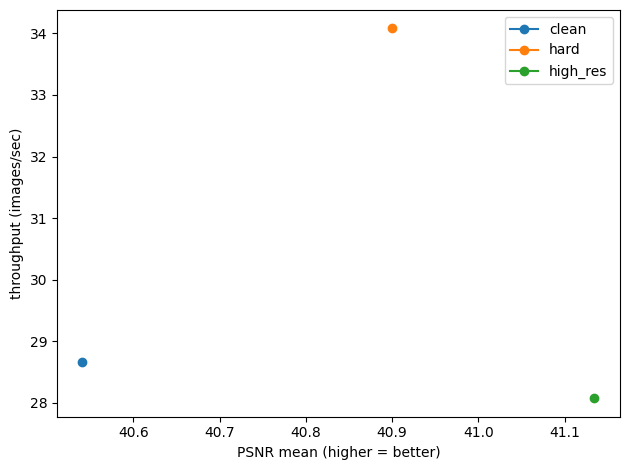

In [62]:
import matplotlib.pyplot as plt

plt.figure()
for ds in sorted(m["dataset"].unique()):
    sub = m[m["dataset"] == ds].sort_values("input_size")
    plt.plot(sub["psnr_mean"], sub["throughput_ips"], marker="o", label=ds)

plt.xlabel("PSNR mean (higher = better)")
plt.ylabel("throughput (images/sec)")
plt.legend()
plt.tight_layout()
plt.show()

График показывает компромисс между скоростью и качеством для разных наборов данных. Более высокое качество не всегда сопровождается высокой пропускной способностью, поэтому выбор конфигурации зависит от того, что в задаче важнее, скорость обработки или сохранение качества изображения

## 10. Практический выбор конфигурации

После сравнения скорости и качества полезно явно выделить рекомендуемые режимы. Ниже для каждого набора данных определяется самая быстрая конфигурация, конфигурация с наилучшим качеством и сбалансированный вариант, который дает высокое качество без слишком большой задержки

In [63]:
recommend_rows = []

for ds in sorted(m["dataset"].unique()):
    sub = m[m["dataset"] == ds].sort_values("input_size").copy()

    fastest = sub.sort_values("latency_p50").iloc[0]
    best_quality = sub.sort_values(["ssim_mean", "psnr_mean"], ascending=False).iloc[0]

    ssim_threshold = sub["ssim_mean"].max() * 0.98
    balanced_pool = sub[sub["ssim_mean"] >= ssim_threshold].copy()
    balanced = balanced_pool.sort_values("latency_p50").iloc[0]

    recommend_rows.append({
        "dataset": ds,
        "fastest_input_size": int(fastest["input_size"]),
        "fastest_latency_p50": float(fastest["latency_p50"]),
        "best_quality_input_size": int(best_quality["input_size"]),
        "best_quality_ssim": float(best_quality["ssim_mean"]),
        "balanced_input_size": int(balanced["input_size"]),
        "balanced_latency_p50": float(balanced["latency_p50"]),
        "balanced_ssim": float(balanced["ssim_mean"]),
    })

recommend_df = pd.DataFrame(recommend_rows)
recommend_df

,dataset,fastest_input_size,fastest_latency_p50,best_quality_input_size,best_quality_ssim,balanced_input_size,balanced_latency_p50,balanced_ssim
0,clean,640,34.890339,640,0.975838,640,34.890339,0.975838
1,hard,640,29.342157,640,0.909145,640,29.342157,0.909145
2,high_res,640,35.622725,640,0.975924,640,35.622725,0.975924


По этой таблице видно, что для всех наборов данных рекомендованным вариантом оказался размер входа 640. Это связано с тем, что в текущем сравнении именно для него доступны и метрики скорости, и метрики качества, поэтому он одновременно определяется как самый быстрый, самый качественный и наиболее сбалансированный. Такой результат показывает, что на данном этапе выбор конфигурации фактически сводится к одному рассмотренному размеру входа


## 11. Краткая сводка основных наблюдений

Ниже приведена компактная сводка ключевых результатов исследования. Она помогает быстро зафиксировать главные выводы по производительности, качеству, устойчивости и практической интерпретации полученных результатов

In [64]:
final_takeaways = pd.DataFrame([
    {
        "aspect": "performance",
        "main_result": "увеличение input_size повышает задержку обработки"
    },
    {
        "aspect": "quality",
        "main_result": "уменьшение input_size ускоряет работу, но снижает PSNR и SSIM"
    },
    {
        "aspect": "stability",
        "main_result": "сложные и high_res изображения сильнее влияют на хвосты распределения"
    },
    {
        "aspect": "robustness",
        "main_result": "искажения ухудшают стабильность пайплайна и меняют latency"
    },
])
final_takeaways

,aspect,main_result
0,performance,увеличение input_size повышает задержку обработки
1,quality,"уменьшение input_size ускоряет работу, но сниж..."
2,stability,сложные и high_res изображения сильнее влияют ...
3,robustness,искажения ухудшают стабильность пайплайна и ме...


Эта таблица нужна для практической интерпретации результатов. Она показывает, какой размер входа дает максимальную скорость, какой дает наилучшее качество и какой вариант можно считать разумным компромиссом.

In [65]:
slow = all_df[(all_df["warmup"] == 0) & (all_df["input_size"] == 640)].copy()
slow = slow.sort_values("total_ms", ascending=False)

top20 = slow.groupby("dataset").head(20)[
    [
        "dataset",
        "image_path",
        "total_ms",
        "load_ms",
        "preprocess_ms",
        "inference_ms",
        "postprocess_ms",
    ]
]
top20

,dataset,image_path,total_ms,load_ms,preprocess_ms,inference_ms,postprocess_ms
1045,hard,/content/drive/MyDrive/kursovaya_images/stress...,68206.967642,68188.842069,16.785706,1.335613,0.001573
401,clean,/content/drive/MyDrive/kursovaya_images/clean/...,56624.827790,56602.199177,21.281654,1.343081,0.001525
400,clean,/content/drive/MyDrive/kursovaya_images/clean/...,50849.878327,50797.370782,48.110492,4.391231,0.003200
402,clean,/content/drive/MyDrive/kursovaya_images/clean/...,2894.963892,2880.730929,13.211200,1.018334,0.001062
2601,high_res,/content/drive/MyDrive/kursovaya_images/high-r...,749.660155,396.966125,350.084171,2.600136,0.005911
2602,high_res,/content/drive/MyDrive/kursovaya_images/high-r...,739.888258,364.024621,374.275408,1.582490,0.002274
2604,high_res,/content/drive/MyDrive/kursovaya_images/high-r...,709.856024,366.169171,342.217605,1.462591,0.002569
2603,high_res,/content/drive/MyDrive/kursovaya_images/high-r...,704.596432,351.791189,350.279510,2.521220,0.001971
2600,high_res,/content/drive/MyDrive/kursovaya_images/high-r...,657.731098,314.190027,341.927385,1.610143,0.001416
2334,high_res,/content/drive/MyDrive/kursovaya_images/high-r...,630.565236,280.170154,348.833417,1.557356,0.001406


Здесь я отдельно выделяю самые медленные изображения для каждого набора данных и смотрю, за счет каких этапов формируется наибольшая задержка. По результатам видно, что самые тяжелые случаи связаны в первую очередь не с инференсом и не с постобработкой, а с загрузкой изображения и предобработкой, причем для отдельных примеров задержка возрастает очень резко. Это подтверждает, что хвост распределения времени определяется особыми входными случаями и что именно этапы чтения данных и подготовки изображения становятся главными источниками нестабильности

In [66]:
from pathlib import Path

OUT = Path("/content/drive/MyDrive/kursovaya_results")
OUT.mkdir(parents=True, exist_ok=True)
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

agg.to_csv(OUT / "agg_perf.csv", index=False)
q_agg.to_csv(OUT / "agg_quality.csv", index=False)
top20.to_csv(OUT / "tail_top20.csv", index=False)

In [68]:
from pathlib import Path
from PIL import Image, ImageFilter
import numpy as np

BASE = Path("/content/drive/MyDrive/kursovaya_images")
clean_dir = BASE / "clean"

corr_base = BASE / "corruptions"
types = ["blur", "noise", "jpeg"]
levels = [1, 2, 3]

for t in types:
    for lvl in levels:
        (corr_base / t / f"l{lvl}").mkdir(parents=True, exist_ok=True)

imgs = sorted(list(clean_dir.glob("*.jpg")) + list(clean_dir.glob("*.jpeg")) + list(clean_dir.glob("*.png")))[:200]

def apply_corruptions(img: Image.Image, t: str, lvl: int) -> Image.Image:
    if t == "blur":
        radius = {1: 1.0, 2: 2.0, 3: 4.0}[lvl]
        return img.filter(ImageFilter.GaussianBlur(radius=radius))
    if t == "noise":
        sigma = {1: 10, 2: 20, 3: 35}[lvl]
        arr = np.array(img, dtype=np.int16)
        noise = np.random.normal(0, sigma, arr.shape).astype(np.int16)
        out = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(out)
    if t == "jpeg":
        return img
    raise ValueError(t)

for p in imgs:
    img0 = Image.open(p).convert("RGB")
    for t in types:
        for lvl in levels:
            out_dir = corr_base / t / f"l{lvl}"
            out_path = out_dir / f"{p.stem}_{t}_l{lvl}.jpg"
            if t == "jpeg":
                q = {1: 75, 2: 50, 3: 25}[lvl]
                img0.save(out_path, quality=q)
            else:
                img1 = apply_corruptions(img0, t, lvl)
                img1.save(out_path, quality=85)

{f"{t}_l{lvl}": len(list((corr_base/t/f"l{lvl}").glob("*.jpg"))) for t in types for lvl in levels}

{'blur_l1': 200,
 'blur_l2': 200,
 'blur_l3': 200,
 'noise_l1': 200,
 'noise_l2': 200,
 'noise_l3': 200,
 'jpeg_l1': 200,
 'jpeg_l2': 200,
 'jpeg_l3': 200}

В этой ячейки я формирую наборы данных с искусственными искажениями для дальнейшей проверки устойчивости пайплайна. Для 200 исходных изображений создаются версии с размытием, шумом и JPEG сжатием на трех уровнях интенсивности, и итоговый вывод показывает, что для каждого типа и каждого уровня удалось успешно подготовить по 200 файлов. Это означает, что наборы для анализа устойчивости собраны полностью и их можно использовать для последующих экспериментов


## 12. Бенчмарк на искаженных изображениях

После подготовки наборов с искажениями выполняется отдельная серия измерений. Ее цель состоит в том, чтобы сравнить поведение пайплайна на исходных и ухудшенных данных и выделить наиболее проблемные сценарии.

In [69]:
DATASETS_CORR = {}
for t in types:
    for lvl in levels:
        DATASETS_CORR[f"{t}_l{lvl}"] = corr_base / t / f"l{lvl}"

paths_corr = []
for name, folder in DATASETS_CORR.items():
    p, _ = benchmark_dataset(name, folder, input_size=640, limit=200, warmup=2, repeats=5)
    print("saved:", p)
    paths_corr.append(p)

len(paths_corr)

saved: /content/drive/MyDrive/kursovaya_results/bench_blur_l1_s640_c0250a5b42.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_blur_l2_s640_b61d8a5952.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_blur_l3_s640_b93330be31.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_noise_l1_s640_65c0fd444f.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_noise_l2_s640_974a336e2a.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_noise_l3_s640_3ec2cc95a9.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_jpeg_l1_s640_eb5acfc065.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_jpeg_l2_s640_8d59c13949.csv
saved: /content/drive/MyDrive/kursovaya_results/bench_jpeg_l3_s640_5116031101.csv


9

## 13. Агрегация результатов на искаженных данных

После запуска измерений на искаженных изображениях результаты необходимо объединить и привести к удобному виду. Это позволяет сравнить разные типы и уровни искажений и увидеть, какие из них сильнее всего влияют на поведение пайплайна.

In [70]:
import pandas as pd

corr_dfs = []
for p in paths_corr:
    df = pd.read_csv(p)
    df = df[df["warmup"] == 0].copy()
    corr_dfs.append(df)

corr_df = pd.concat(corr_dfs, ignore_index=True)

corr_df["corruption_type"] = corr_df["dataset"].str.extract(r"^(blur|noise|jpeg)")
corr_df["level"] = corr_df["dataset"].str.extract(r"_l(\d+)").astype(int)

corr_agg = corr_df.groupby(["corruption_type", "level"]).agg(
    latency_p50=("total_ms", lambda s: s.quantile(0.5)),
    latency_p95=("total_ms", lambda s: s.quantile(0.95)),
    load_ms=("load_ms", "mean"),
    preprocess_ms=("preprocess_ms", "mean"),
    inference_ms=("inference_ms", "mean"),
    postprocess_ms=("postprocess_ms", "mean"),
).reset_index()

corr_agg.sort_values(["corruption_type", "level"])

,corruption_type,level,latency_p50,latency_p95,load_ms,preprocess_ms,inference_ms,postprocess_ms
0,blur,1,27.019823,46.981179,11.726392,20.087202,1.229700,0.001084
1,blur,2,26.373399,45.141576,10.843440,18.850080,1.179916,0.001090
2,blur,3,26.722852,45.649282,10.698382,20.044782,1.219525,0.001327
3,jpeg,1,26.968956,44.728993,11.138954,18.517184,1.174631,0.001069
4,jpeg,2,27.676043,44.509107,10.754853,19.590477,1.234771,0.001230
5,jpeg,3,25.624532,43.558886,9.934629,19.117418,1.170860,0.001134
6,noise,1,30.134665,50.314881,14.707762,19.317411,1.218768,0.001182
7,noise,2,31.224574,53.029367,16.235029,19.230607,1.214630,0.001230
8,noise,3,33.062871,55.723651,18.419781,19.232449,1.219591,0.001177


В этой части я объединяю результаты прогонов на искаженных изображениях и сравниваю, как разные типы и уровни искажений влияют на время обработки. По таблице видно, что наибольшее влияние оказывает шум: с ростом его уровня увеличиваются и медианная задержка, и верхний квантиль, а также возрастает время загрузки изображения. Размытие и JPEG сжатие влияют слабее и дают более стабильные значения, поэтому именно шум в этом эксперименте оказывается наиболее чувствительным сценарием для устойчивости пайплайна

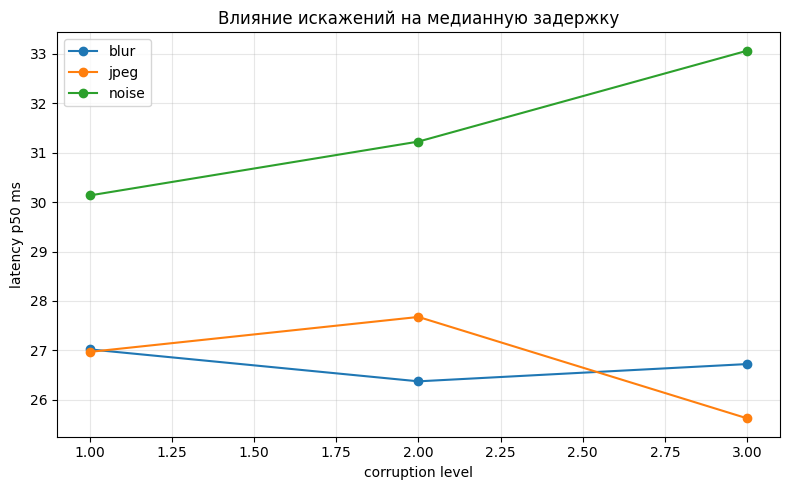

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for t in sorted(corr_agg["corruption_type"].unique()):
    sub = corr_agg[corr_agg["corruption_type"] == t].sort_values("level")
    plt.plot(sub["level"], sub["latency_p50"], marker="o", label=t)

plt.xlabel("corruption level")
plt.ylabel("latency p50 ms")
plt.title("Влияние искажений на медианную задержку")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

По графику видно, что наиболее заметное влияние на медианную задержку оказывает шум. С ростом уровня шумового искажения задержка последовательно увеличивается, тогда как для размытия и JPEG сжатия изменения остаются небольшими и не образуют такого выраженного тренда. Это показывает, что именно шум сильнее всего влияет на устойчивость пайплайна по времени обработки

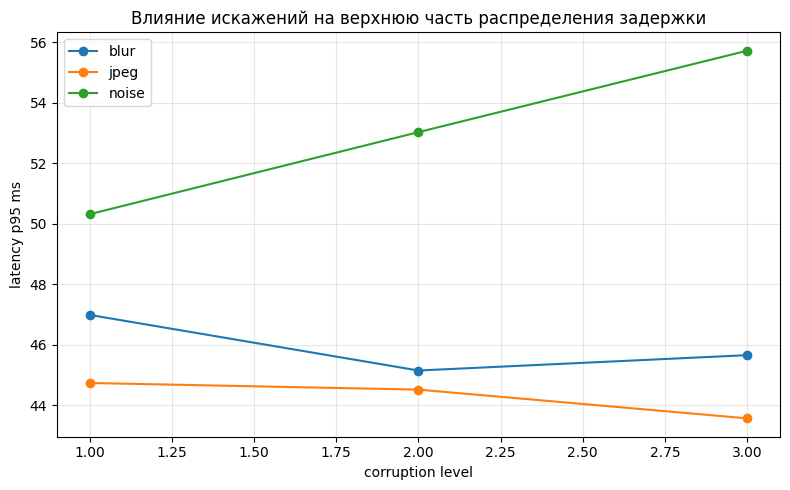

In [72]:
plt.figure(figsize=(8, 5))
for t in sorted(corr_agg["corruption_type"].unique()):
    sub = corr_agg[corr_agg["corruption_type"] == t].sort_values("level")
    plt.plot(sub["level"], sub["latency_p95"], marker="o", label=t)

plt.xlabel("corruption level")
plt.ylabel("latency p95 ms")
plt.title("Влияние искажений на верхнюю часть распределения задержки")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

График показывает, что на верхнюю часть распределения задержки сильнее всего влияет шум. С ростом уровня шумового искажения значение p95 последовательно увеличивается, то есть самые тяжелые случаи становятся еще более медленными. Для размытия и JPEG сжатия такого роста не наблюдается, поэтому именно шум сильнее всего ухудшает устойчивость пайплайна в наиболее проблемных сценариях

In [73]:
worst_corr = corr_agg.sort_values("latency_p95", ascending=False).reset_index(drop=True)
worst_corr

,corruption_type,level,latency_p50,latency_p95,load_ms,preprocess_ms,inference_ms,postprocess_ms
0,noise,3,33.062871,55.723651,18.419781,19.232449,1.219591,0.001177
1,noise,2,31.224574,53.029367,16.235029,19.230607,1.214630,0.001230
2,noise,1,30.134665,50.314881,14.707762,19.317411,1.218768,0.001182
3,blur,1,27.019823,46.981179,11.726392,20.087202,1.229700,0.001084
4,blur,3,26.722852,45.649282,10.698382,20.044782,1.219525,0.001327
5,blur,2,26.373399,45.141576,10.843440,18.850080,1.179916,0.001090
6,jpeg,1,26.968956,44.728993,11.138954,18.517184,1.174631,0.001069
7,jpeg,2,27.676043,44.509107,10.754853,19.590477,1.234771,0.001230
8,jpeg,3,25.624532,43.558886,9.934629,19.117418,1.170860,0.001134


По этой таблице видно, что наихудшие значения p95 связаны со всеми уровнями шумового искажения, причем наиболее тяжелым случаем оказывается noise уровня 3. Это означает, что именно шум сильнее всего ухудшает поведение пайплайна в медленных и нестабильных сценариях. Размытие и JPEG сжатие тоже влияют на задержку, но заметно слабее и не дают такого роста верхней части распределения

## 14. Анализ рисков эксплуатации

Полученные результаты позволяют выделить несколько практических рисков:

1) увеличение размера входа приводит к росту задержки и делает систему менее устойчивой по времени обработки



2) сложные изображения и изображения высокого разрешения сильнее формируют хвост распределения задержек, а значит создают риск нестабильной работы в реальном использовании



3) уменьшение размера входа ускоряет обработку, но сопровождается ухудшением качества изображения после преобразования



4) оценка только на чистых данных приводит к слишком оптимистичному представлению о поведении пайплайна, так как при искажениях характеристики могут заметно ухудшаться



Таким образом, ключевые риски связаны с нестабильностью времени обработки на тяжелых данных, с потерей качества при агрессивном уменьшении входа и с недостаточной устойчивостью к искажениям входных изображений

## 15. Ограничения исследования

Проведенное исследование позволяет сделать содержательные выводы, однако имеет несколько ограничений:

1. рассматриваемый пайплайн является тестовым и предназначен прежде всего для изучения вычислительных свойств обработки изображений, а не для оценки точности конкретной прикладной модели компьютерного зрения

2. используемые наборы данных отражают несколько характерных сценариев, но не покрывают все возможные условия эксплуатации и не позволяют полностью описать поведение системы на любых входных данных

3. анализ сосредоточен на влиянии параметров обработки и типовых искажений входных изображений, тогда как влияние аппаратной платформы, особенностей окружения и более сложных режимов исполнения рассматривается ограниченно

4. часть выводов получена на основе ограниченного набора конфигураций, поэтому при расширении числа параметров или использовании других данных соотношение между скоростью, качеством и устойчивостью может измениться

Основные ограничения связаны с тестовым характером пайплайна, ограниченной полнотой данных и тем, что исследование охватывает только часть факторов, влияющих на поведение системы.




## 16. Практические рекомендации

По итогам экспериментов можно выделить несколько практических рекомендаций:

1. если важнее всего скорость обработки, стоит уменьшать размер входного изображения, но такой выбор нужно обязательно проверять по метрикам качества

2. если нужен более ровный баланс между качеством и временем работы, лучше ориентироваться на конфигурации с высокими значениями SSIM без заметного роста задержки

3. для изображений высокого разрешения и для более сложных примеров стоит заранее контролировать размер входа и отдельно следить за верхними квантилями времени обработки

4. при использовании пайплайна в реальной системе валидацию лучше проводить не только на чистых данных, но и на изображениях с типовыми искажениями, а в мониторинге учитывать не только средние значения, но и p95

Выбор рабочей конфигурации должен опираться не на одну метрику, а на сочетание требований к скорости, качеству и устойчивости.





## 17. Проверка гипотезы

Исходная гипотеза в ходе исследования подтвердилась.

1. между скоростью обработки, качеством изображения и устойчивостью пайплайна действительно наблюдается выраженный компромисс

2. изменение размера входного изображения приводит к заметным изменениям как во времени обработки, так и в показателях качества после преобразования

3. разные типы данных влияют на поведение системы по-разному, а наиболее сложные и тяжелые случаи сильнее отражаются на стабильности результатов

4. вклад отдельных этапов в общую задержку оказывается неодинаковым, поэтому поведение пайплайна определяется не всей цепочкой сразу, а несколькими наиболее чувствительными компонентами

Гипотеза о том, что параметры обработки и свойства входных данных влияют на баланс между скоростью, качеством и устойчивостью, получила экспериментальное подтверждение.






## 18. Общие выводы

В ходе работы я исследовала тестовый пайплайн компьютерного зрения на нескольких наборах данных, различающихся по сложности и разрешению. Эксперименты показали, что увеличение размера входного изображения сопровождается ростом задержки обработки, а распределение времени по этапам остается неравномерным. Анализ вариативности измерений показал, что предсказуемость работы зависит не только от выбранной конфигурации, но и от особенностей самих изображений. Оценка качества с помощью PSNR и SSIM подтвердила, что ускорение обработки связано с потерей части визуальной информации. Проверка на искаженных данных показала, что анализ только на чистых изображениях не позволяет полноценно судить об устойчивости пайплайна.

В конечном итоге мне удалось выделить чувствительные конфигурации, описать основные риски эксплуатации и сформулировать рекомендации по выбору более устойчивого и сбалансированного режима работы